In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.backend import BackendPolicy, backend
from src.layers import Conv1D, Dense
from src.layers.activation import Flatten, ReLU, Softmax, Tanh,ELU, LeakyReLU
from src.loss.cross_entropy import CrossEntropy
from src.models.neural_network import Network
from src.models.sequential import Sequential
from src.optimizer.adam import Adam
from src.layers.activation.dropout import Dropout
from src.layers.global_concat_pool import GlobalConcatPool1D
from src.layers.masked_global_average import MaskedGlobalAveragePool1D


In [6]:
def prepare_har_dataset(csv_path: str, mode: str = "all"):
    """
    mode: 'xyz' (6 channels), 'mag' (2 channels), or 'all' (8 channels)
    """
    raw_data = np.genfromtxt(csv_path, delimiter=",")
    Y = raw_data[:, 9000].astype("int32")
    features_raw = raw_data[:, :9000].astype("float32")
    lengths = raw_data[:, 9001]
    num_samples = features_raw.shape[0]
    time_steps = 1500

    X_6 = np.zeros((num_samples, time_steps, 6), dtype="float32")
    for i in range(6):
        X_6[:, :, i] = features_raw[:, i*time_steps : (i+1)*time_steps]

    acc_mag = np.linalg.norm(X_6[:, :, 0:3], axis=2, keepdims=True)
    gyro_mag = np.linalg.norm(X_6[:, :, 3:6], axis=2, keepdims=True)

    if mode == "xyz":
        X_data = X_6
    elif mode == "mag":
        X_data = np.concatenate([acc_mag, gyro_mag], axis=2)
    else:
        X_data = np.concatenate([X_6, acc_mag, gyro_mag], axis=2)

    num_ch = X_data.shape[2]
    scaler = StandardScaler()
    X_flat = X_data.reshape(-1, num_ch)
    X_scaled_flat = scaler.fit_transform(X_flat)
    X_final = X_scaled_flat.reshape(num_samples, time_steps, num_ch)
    mask = np.arange(time_steps) < lengths[:, None]
    X_final[~mask] = 0.0
    X_final = np.transpose(X_final, (0, 2, 1))

    return X_final, Y, lengths, scaler

def remap_dataset(X, Y, lengths, config):
    new_X, new_Y, new_lengths = [], [], []
    unique_labels = sorted(set(config.values()))
    label_to_id = {name: i for i, name in enumerate(unique_labels)}
    for i in range(len(Y)):
        old_id = int(Y[i])
        if old_id in config:
            new_X.append(X[i])
            new_lengths.append(lengths[i])
            new_Y.append(label_to_id[config[old_id]])
    return np.array(new_X), np.array(new_Y), np.array(new_lengths), unique_labels

In [2]:
dataset_path = r"data\KU-HAR_v1.0_raw_samples.csv"
num_classes = 18
activity_map = {
    0: "Stand", 1: "Sit", 2: "Talk-sit", 3: "Talk-stand", 4: "Stand-sit",
    5: "Lay", 6: "Lay-stand", 7: "Pick", 8: "Jump", 9: "Push-up",
    10: "Sit-up", 11: "Walk", 12: "Walk-backward", 13: "Walk-circle",
    14: "Run", 15: "Stair-up", 16: "Stair-down", 17: "Table-tennis"
}
merge_config = {
    0: "Stand", 3: "Stand",
    1: "Sit", 2: "Sit",
    4: "Sit",                       # Stand-sit (merged to Sit)
    5: "Lay", 6: "Stand",           # Lay / Lay-stand (merged to Stand)
    8: "Jump",
    11: "Walk", 12: "Walk", 13: "Walk", # Walk + Backward + Circle
    14: "Run",
    15: "Stairs", 16: "Stairs"      # Up + Down
}


In [7]:

X_raw, Y_raw, lengths_raw, scaler = prepare_har_dataset(dataset_path, mode='all')
X_remapped, Y_remapped, lengths_remapped, labels = remap_dataset(
    X_raw, Y_raw, lengths_raw, merge_config
)
indices = np.arange(X_remapped.shape[0])
np.random.shuffle(indices)
X_remapped = X_remapped[indices]
Y_remapped = Y_remapped[indices]
lengths_remapped = lengths_remapped[indices]

In [8]:
X_train, x_test, Y_train, Y_test, lengths_train, lengths_test = train_test_split(
    X_remapped, Y_remapped, lengths_remapped, test_size=0.2, random_state=2
)

# Re-assign one-hot encoded targets to Y_train and Y_test so the remaining functions work smoothly
num_classes = len(labels)
Y_train = np.eye(num_classes)[Y_train.astype(int)]
Y_test = np.eye(num_classes)[Y_test.astype(int)]

# Redefine the dictionary map for the plotting matrix because we updated labels


In [9]:
activity_map = {i: label for i, label in enumerate(labels)}

In [6]:
from src.layers.batch_normalization import BatchNormalization


backend.configure(policy=BackendPolicy(use_gpu=True), dataset_bytes=1024*1024*1024*1024)
optimizer = Adam(learning_rate=1e-3)
loss_fn = CrossEntropy()
model = Sequential([
    Conv1D(filters=32, kernel_size=31, stride=1, padding=15, name="conv1"),
    BatchNormalization(),
    LeakyReLU(),
    Conv1D(filters=64, kernel_size=15, stride=2, padding=7, name="conv2"),
    BatchNormalization(),
    LeakyReLU(),
    Dropout(0.2),
    Conv1D(filters=128, kernel_size=7, stride=2, padding=3, name="conv3"),
    BatchNormalization(),
    ELU(),
    GlobalConcatPool1D(name="masked_gap"),
    Dense(128),
    BatchNormalization(),
    ELU(),
    Dropout(0.5),
    Dense(len(labels)),
    Softmax()
])

model.scaler = scaler
model.activity_labels = labels
model.compile(optimizer=optimizer, loss=loss_fn)


history, total_time = model.fit(X_train, Y_train, epochs=150, batch_size=128, verbose=5, mask=lengths_train, lr_decay_epochs=30, lr_decay=0.5)
model.save(r"models\har_model_hybrid_v3.nnp")

2026-03-22 12:45:26,633 | INFO | src.backend | GPU requested. Dataset size: 1099511627776 bytes. Minimum for GPU: 8000000 bytes.
2026-03-22 12:45:27,055 | INFO | src.backend | CuPy available: True.
2026-03-22 12:45:27,056 | INFO | src.backend | Using backend: cupy
Epoch 1/150 - Loss: 1.183271 - 12.08s/epoch - ETA: 00:30:00
Epoch 6/150 - Loss: 0.429581 - 11.87s/epoch - ETA: 00:28:32
Epoch 11/150 - Loss: 0.354105 - 11.85s/epoch - ETA: 00:27:30
Epoch 16/150 - Loss: 0.316624 - 11.86s/epoch - ETA: 00:26:30
Epoch 21/150 - Loss: 0.272676 - 11.86s/epoch - ETA: 00:25:31
Epoch 26/150 - Loss: 0.241016 - 11.85s/epoch - ETA: 00:24:31
Epoch 30: Learning rate decayed to 0.000500
Epoch 31/150 - Loss: 0.211421 - 11.89s/epoch - ETA: 00:23:32
Epoch 36/150 - Loss: 0.192423 - 11.86s/epoch - ETA: 00:22:32
Epoch 41/150 - Loss: 0.180510 - 11.86s/epoch - ETA: 00:21:33
Epoch 46/150 - Loss: 0.176506 - 11.90s/epoch - ETA: 00:20:34
Epoch 51/150 - Loss: 0.172527 - 11.86s/epoch - ETA: 00:19:34
Epoch 56/150 - Loss: 0

In [12]:
_loaded = Network.load(r"models\har_model_hybrid_v3.nnp")
print(_loaded.scaler)

StandardScaler()


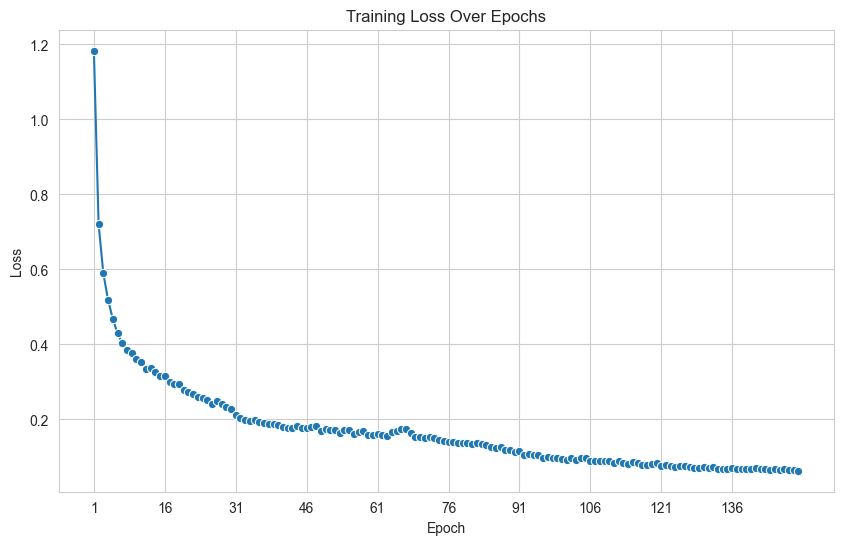

In [7]:
def plot_training_history(history, title="Training Loss Over Epochs"):
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=range(1, len(history) + 1), y=history, marker="o")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(range(1, len(history) + 1, max(1, len(history) // 10)))
    plt.show()

plot_training_history(history)

In [13]:
def plot_confusion_matrix(x_test, y_test, model, lengths_test, activity_map):
    predictions = model.predict(x_test, mask=lengths_test)
    y_true = np.argmax(y_test, axis=1)
    y_pred = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=[activity_map[i] for i in range(num_classes)]))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[activity_map[i] for i in range(num_classes)], yticklabels=[activity_map[i] for i in range(num_classes)])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

Test Accuracy: 0.9633
Test F1 Score: 0.9618
Classification Report:
              precision    recall  f1-score   support

        Jump       0.99      1.00      1.00       101
         Lay       0.98      0.71      0.82       120
         Run       1.00      0.98      0.99        94
         Sit       0.92      0.98      0.95       413
      Stairs       1.00      1.00      1.00       220
       Stand       0.96      0.98      0.97       332
        Walk       1.00      0.99      1.00       191

    accuracy                           0.96      1471
   macro avg       0.98      0.95      0.96      1471
weighted avg       0.96      0.96      0.96      1471



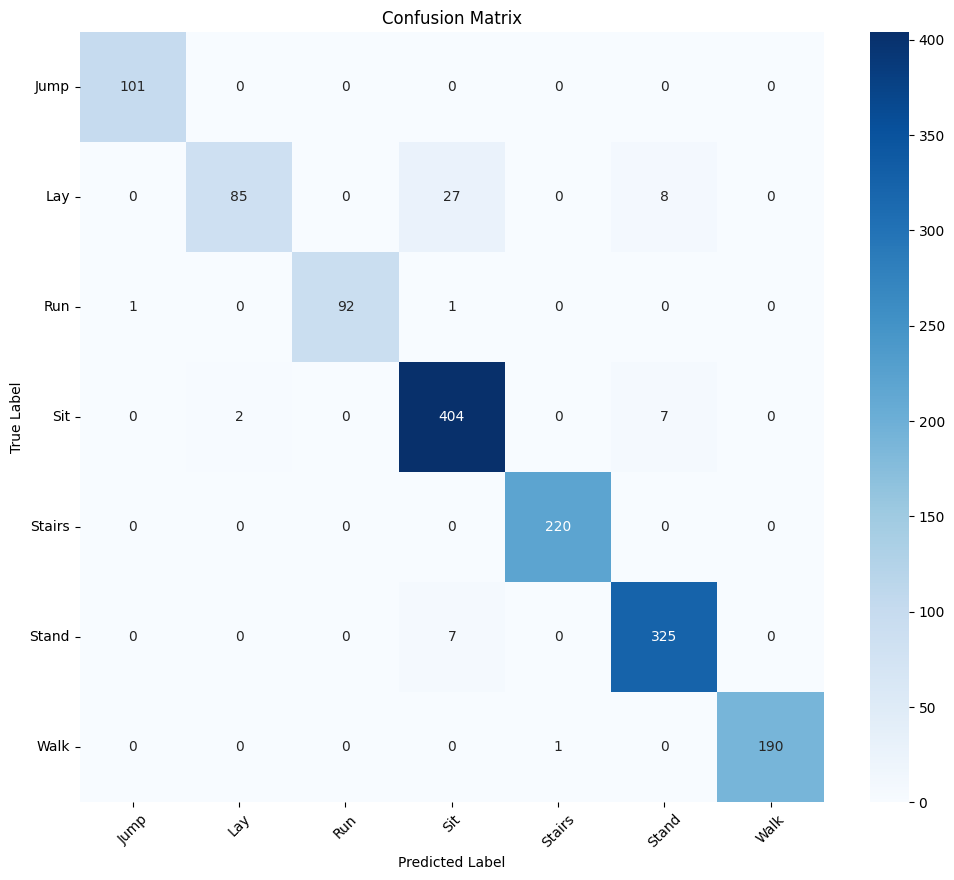

In [15]:
plot_confusion_matrix(x_test, Y_test, _loaded, lengths_test=lengths_test, activity_map=_loaded.activity_labels)

In [15]:

def compare_gpu_vs_cpu(X, Y, model: Network, epochs=1, batch_size=64, verbose=5):
    if not backend._cupy_runtime_ok:
        print("GPU runtime not available. Skipping GPU vs CPU comparison.")
        return -1,-1
    backend.configure(policy=BackendPolicy(use_gpu=False), dataset_bytes=0)
    model.reset()
    X_cpu, Y_cpu = backend.asarray(X), backend.asarray(Y)
    _, cpu_time = model.fit(X_cpu, Y_cpu, epochs=epochs, batch_size=batch_size, verbose=verbose)
    model.reset()
    backend.configure(policy=BackendPolicy(use_gpu=True, min_gpu_bytes=0), dataset_bytes=10)
    X_gpu, Y_gpu = backend.asarray(X), backend.asarray(Y)
    _, gpu_time = model.fit(X_gpu, Y_gpu, epochs=epochs, batch_size=batch_size, verbose=verbose)
    return cpu_time, gpu_time

cpu_time, gpu_time = compare_gpu_vs_cpu(X, Y, model, epochs=25, batch_size=1024, verbose=5)
print(f"CPU time: {cpu_time:.2f} seconds")
print(f"GPU time: {gpu_time:.2f} seconds")
print(f"Speedup: {cpu_time / gpu_time:.2f}x")



2026-03-21 21:56:52,311 | INFO | src.backend | Using backend: numpy


KeyboardInterrupt: 